In [ ]:
CatBoost is probably the BEST first enterprise-grade model for your Repo 5.

Because your dataset has:

rich categoricals,
missing values,
nonlinear interactions,
behavioral features,
moderate tabular scale.

This is exactly where CatBoost shines.

ENTERPRISE CATBOOST PIPELINE ⭐⭐⭐⭐⭐

We will follow proper enterprise steps:

Step	Purpose
1	prepare final dataset
2	define target
3	define categorical features
4	split train/test
5	create CatBoost pools
6	train model
7	evaluate
8	inspect feature importance
9	SHAP explainability
10	probability calibration

In [173]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# LOAD PD DATASET
# ============================================================

pd_df = pd.read_parquet(

    "/home/muzzi/enterprise_credit_risk_forecasting/data/pd_dataset.parquet"
)

# ============================================================
# CHECK DATA
# ============================================================

print(pd_df.shape)

pd_df.head()

(50000, 119)


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,emp_title,emp_length,home_ownership,annual_inc,verification_status,...,issue_quarter,all_util_missing,il_util_missing,mths_since_last_delinq_missing,term_months,emp_length_years,zip_region,emp_title_clean,job_cluster,TARGET
0,3600.0,3600.0,3600.0,13.99,123.03,leadman,10+ years,MORTGAGE,55000.0,Not Verified,...,4,0,0,0,36.0,10.0,190,leadman,other,0.0
1,24700.0,24700.0,24700.0,11.99,820.28,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,...,4,0,0,0,36.0,10.0,577,engineer,engineering,0.0
2,20000.0,20000.0,20000.0,10.78,432.66,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,...,4,0,0,1,60.0,10.0,605,truck driver,transportation,0.0
3,35000.0,35000.0,35000.0,14.85,829.90,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,...,4,0,0,1,60.0,10.0,076,information systems officer,other,NaN
4,10400.0,10400.0,10400.0,22.45,289.91,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,...,4,0,0,0,60.0,3.0,174,contract specialist,other,0.0


In [174]:
### advance features

# ============================================================
# ADVANCED ENTERPRISE FEATURE ENGINEERING
# ============================================================

import numpy as np

# ============================================================
# AFFORDABILITY / PAYMENT STRESS
# ============================================================

# Monthly income proxy
pd_df["monthly_income"] = (

    pd_df["annual_inc"] / 12
)

# Installment burden
pd_df["installment_to_income"] = (

    pd_df["installment"]

    / pd_df["monthly_income"]
)

# Loan burden
pd_df["loan_to_income"] = (

    pd_df["loan_amnt"]

    / pd_df["annual_inc"]
)

# Revolving debt burden
pd_df["revolving_to_income"] = (

    pd_df["revol_bal"]

    / pd_df["annual_inc"]
)

# ============================================================
# CREDIT UTILIZATION STRESS
# ============================================================

# Revolving utilization × DTI
pd_df["utilization_dti_stress"] = (

    pd_df["revol_util"]

    * pd_df["dti"]
)

# Bankcard utilization × DTI
pd_df["bcutil_dti_stress"] = (

    pd_df["bc_util"]

    * pd_df["dti"]
)

# Utilization per account
pd_df["util_per_account"] = (

    pd_df["revol_bal"]

    / (pd_df["open_acc"] + 1)
)

# ============================================================
# CREDIT HUNGER / AGGRESSIVE BORROWING
# ============================================================

# Recent inquiries + new trades
pd_df["credit_hunger"] = (

    pd_df["inq_last_6mths"]

    + pd_df["acc_open_past_24mths"]
)

# Inquiry intensity normalized by history
pd_df["inq_per_year"] = (

    pd_df["inq_last_6mths"]

    / (

        (pd_df["credit_history_months"] / 12)

        + 1
    )
)

# Recent accounts pressure
pd_df["recent_account_pressure"] = (

    pd_df["num_tl_op_past_12m"]

    / (pd_df["total_acc"] + 1)
)

# ============================================================
# CREDIT EXPERIENCE / STABILITY
# ============================================================

# Average account age proxy
pd_df["avg_account_age"] = (

    pd_df["credit_history_months"]

    / (pd_df["total_acc"] + 1)
)

# Trade density
pd_df["trade_density"] = (

    pd_df["total_acc"]

    / (

        (pd_df["credit_history_months"] / 12)

        + 1
    )
)

# Revolving lines share
pd_df["revolving_trade_share"] = (

    pd_df["num_rev_accts"]

    / (pd_df["total_acc"] + 1)
)

# Installment lines share
pd_df["installment_trade_share"] = (

    pd_df["num_il_tl"]

    / (pd_df["total_acc"] + 1)
)

# ============================================================
# FICO INTERACTION FEATURES
# ============================================================

# Utilization adjusted by FICO
pd_df["utilization_per_fico"] = (

    pd_df["revol_util"]

    / (pd_df["fico_range_low"] + 1)
)

# DTI adjusted by FICO
pd_df["dti_per_fico"] = (

    pd_df["dti"]

    / (pd_df["fico_range_low"] + 1)
)

# Loan burden adjusted by FICO
pd_df["loan_per_fico"] = (

    pd_df["loan_amnt"]

    / (pd_df["fico_range_low"] + 1)
)

# ============================================================
# DELINQUENCY STRESS
# ============================================================

# Delinquency intensity
pd_df["delinq_intensity"] = (

    pd_df["delinq_2yrs"]

    / (

        (pd_df["credit_history_months"] / 12)

        + 1
    )
)

# Public derogatory burden
pd_df["derogatory_pressure"] = (

    pd_df["pub_rec"]

    + pd_df["pub_rec_bankruptcies"]
)

# ============================================================
# LIQUIDITY / CAPACITY
# ============================================================

# Available revolving capacity
pd_df["remaining_revolving_capacity"] = (

    pd_df["total_rev_hi_lim"]

    - pd_df["revol_bal"]
)

# Available bankcard capacity
pd_df["remaining_bc_capacity"] = (

    pd_df["total_bc_limit"]

    - (

        pd_df["bc_util"] / 100

        * pd_df["total_bc_limit"]
    )
)

# ============================================================
# LONG TERM RISK STRUCTURE
# ============================================================

# Long term installment stress
pd_df["long_term_stress"] = (

    pd_df["term_months"]

    * pd_df["installment_to_income"]
)

# Long duration leverage
pd_df["term_loan_burden"] = (

    pd_df["term_months"]

    * pd_df["loan_to_income"]
)

# ============================================================
# ACCOUNT SATURATION
# ============================================================

# Active trade saturation
pd_df["active_trade_ratio"] = (

    pd_df["num_actv_rev_tl"]

    / (pd_df["total_acc"] + 1)
)

# Open account saturation
pd_df["open_account_ratio"] = (

    pd_df["open_acc"]

    / (pd_df["total_acc"] + 1)
)

# ============================================================
# CLEAN INFINITE VALUES
# ============================================================

pd_df = pd_df.replace(

    [np.inf, -np.inf],

    np.nan
)

print("Advanced feature engineering complete.")

Advanced feature engineering complete.


In [175]:
# ============================================================
# FEATURE DOCUMENTATION TABLE
# ============================================================

feature_docs = pd.DataFrame({

    "feature": [

        "monthly_income",
        "installment_to_income",
        "loan_to_income",
        "revolving_to_income",
        "utilization_dti_stress",
        "bcutil_dti_stress",
        "util_per_account",
        "credit_hunger",
        "inq_per_year",
        "recent_account_pressure",
        "avg_account_age",
        "trade_density",
        "revolving_trade_share",
        "installment_trade_share",
        "utilization_per_fico",
        "dti_per_fico",
        "loan_per_fico",
        "delinq_intensity",
        "derogatory_pressure",
        "remaining_revolving_capacity",
        "remaining_bc_capacity",
        "long_term_stress",
        "term_loan_burden",
        "active_trade_ratio",
        "open_account_ratio"
    ],

    "formula": [

        "annual_inc / 12",
        "installment / monthly_income",
        "loan_amnt / annual_inc",
        "revol_bal / annual_inc",
        "revol_util * dti",
        "bc_util * dti",
        "revol_bal / open_acc",
        "inq_last_6mths + acc_open_past_24mths",
        "inq_last_6mths / (credit_history_months/12)",
        "num_tl_op_past_12m / total_acc",
        "credit_history_months / total_acc",
        "total_acc / (credit_history_months/12)",
        "num_rev_accts / total_acc",
        "num_il_tl / total_acc",
        "revol_util / fico_range_low",
        "dti / fico_range_low",
        "loan_amnt / fico_range_low",
        "delinq_2yrs / (credit_history_months/12)",
        "pub_rec + pub_rec_bankruptcies",
        "total_rev_hi_lim - revol_bal",
        "total_bc_limit - utilized_bc_amount",
        "term_months * installment_to_income",
        "term_months * loan_to_income",
        "num_actv_rev_tl / total_acc",
        "open_acc / total_acc"
    ],

    "business_meaning": [

        "Estimated monthly borrower income",
        "Monthly payment affordability stress",
        "Loan leverage relative to income",
        "Revolving debt burden relative to income",
        "Combined leverage and utilization stress",
        "Bankcard-specific debt stress",
        "Average revolving exposure per account",
        "Aggressive borrowing behavior indicator",
        "Normalized inquiry intensity",
        "Recent account opening pressure",
        "Credit profile maturity proxy",
        "Credit expansion speed",
        "Dependence on revolving credit",
        "Dependence on installment credit",
        "Utilization adjusted by credit quality",
        "Debt burden adjusted by FICO",
        "Loan size adjusted by credit quality",
        "Delinquency frequency intensity",
        "Combined derogatory credit burden",
        "Remaining revolving liquidity cushion",
        "Remaining bankcard borrowing capacity",
        "Long-duration affordability stress",
        "Long-term leverage burden",
        "Share of active revolving trades",
        "Ratio of open accounts to total accounts"
    ]
})

# ============================================================
# DISPLAY
# ============================================================

display(

    feature_docs
)

# ============================================================
# OPTIONAL SAVE
# ============================================================

feature_docs.to_csv(

    "data/pd_feature_documentation.csv",

    index=False
)

,feature,formula,business_meaning
0,monthly_income,annual_inc / 12,Estimated monthly borrower income
1,installment_to_income,installment / monthly_income,Monthly payment affordability stress
2,loan_to_income,loan_amnt / annual_inc,Loan leverage relative to income
3,revolving_to_income,revol_bal / annual_inc,Revolving debt burden relative to income
4,utilization_dti_stress,revol_util * dti,Combined leverage and utilization stress
5,bcutil_dti_stress,bc_util * dti,Bankcard-specific debt stress
6,util_per_account,revol_bal / open_acc,Average revolving exposure per account
7,credit_hunger,inq_last_6mths + acc_open_past_24mths,Aggressive borrowing behavior indicator
8,inq_per_year,inq_last_6mths / (credit_history_months/12),Normalized inquiry intensity
9,recent_account_pressure,num_tl_op_past_12m / total_acc,Recent account opening pressure


In [ ]:
VERY IMPORTANT PRINCIPLE ⭐⭐⭐⭐⭐

The best PD features usually capture:

| Concept                | Real Meaning                          |
| ---------------------- | ------------------------------------- |
| borrower stress        | inability to absorb shocks            |
| liquidity fragility    | no remaining capacity                 |
| aggressive expansion   | rapidly increasing leverage           |
| structural instability | thin/maturing credit profile          |
| debt dependency        | over-reliance on borrowing            |
| credit deterioration   | worsening behavior                    |
| hidden leverage        | burden not obvious from raw variables |


In [177]:
pd_df["liquidity_exhaustion"] = (

    pd_df["revol_bal"]

    / (pd_df["total_rev_hi_lim"] + 1)
)

pd_df["credit_velocity"] = (

    pd_df["total_acc"]

    / (

        (pd_df["credit_history_months"] / 12)

        + 1
    )
)

pd_df["leverage_acceleration"] = (

    pd_df["revol_util"]

    * pd_df["acc_open_past_24mths"]

    * (pd_df["inq_last_6mths"] + 1)
)
pd_df["credit_fatigue"] = (

    pd_df["num_actv_rev_tl"]

    / (

        (pd_df["credit_history_months"] / 12)

        + 1
    )
)
pd_df["debt_saturation"] = (

    pd_df["total_bal_ex_mort"]

    / (pd_df["annual_inc"] + 1)
)

pd_df["revolving_dependency"] = (

    pd_df["revol_bal"]

    / (

        pd_df["total_bal_ex_mort"]

        + 1
    )
)

pd_df["payment_stress_amplification"] = (

    pd_df["installment_to_income"]

    * pd_df["dti"]
)

pd_df["fico_stress"] = (

    pd_df["revol_util"]

    * pd_df["dti"]

    / (pd_df["fico_range_low"] + 1)
)
pd_df["account_fragmentation"] = (

    pd_df["open_acc"]

    / (

        pd_df["num_rev_accts"]

        + 1
    )
)

pd_df["borrower_complexity"] = (

    pd_df["open_acc"]

    + pd_df["num_rev_accts"]

    + pd_df["num_il_tl"]

    + pd_df["acc_open_past_24mths"]
)

pd_df["utilization_shock_risk"] = (

    pd_df["revol_util"]

    * (

        pd_df["num_tl_op_past_12m"]

        + 1
    )
)
pd_df["credit_resilience"] = (

    pd_df["credit_history_months"]

    * (pd_df["fico_range_low"] + 1)

    / (

        pd_df["dti"]

        + 1
    )
)

In [ ]:
THE MODEL IS NOW LEARNING "RISK REGIMES" ⭐⭐⭐⭐⭐

Instead of:

high DTI = risky

it now learns things like:

high DTI
+
rapid borrowing
+
high utilization
+
long term burden
=
dangerous regime

This is MUCH more enterprise-grade.

VERY IMPORTANT FEATURE ⭐⭐⭐⭐⭐
leverage_acceleration
revol_util
*
acc_open_past_24mths
*
(inq_last_6mths + 1)

Importance:

3.10

This is HUGE.

WHY THIS FEATURE IS POWERFUL ⭐⭐⭐⭐⭐

It captures:

Behavior
borrower already highly utilized
still opening new accounts
still making inquiries

This often indicates:

financially stressed expansion behavior.

VERY realistic underwriting signal.

long_term_stress ⭐⭐⭐⭐⭐
term_months * installment_to_income

This is VERY enterprise-like.

Because:

not just affordability,
BUT affordability sustained over long duration.

This is VERY important in unsecured lending.

payment_stress_amplification ⭐⭐⭐⭐⭐
installment_to_income * dti

Excellent feature.

Captures:

existing debt burden,
PLUS:
new loan burden.

This is MUCH smarter than:

DTI alone
credit_resilience ⭐⭐⭐⭐⭐

VERY interesting.

This is:

inverse-risk engineering.

You created:

(history * fico) / dti

This measures:

stability,
credit quality,
manageable leverage.

VERY sophisticated underwriting concept.

THIS IS IMPORTANT ⭐⭐⭐⭐⭐

Most ML engineers ONLY create:

risk amplification features.

But:

resilience features

are equally valuable.

This is VERY mature modeling thinking.

VERY IMPORTANT OBSERVATION ⭐⭐⭐⭐⭐

Notice:
classic raw variables now reduced:

Raw Feature	Importance
dti	1.53
fico_low	1.92

while:
interaction features increased.

This usually means:

the model found better structural representations.

VERY good sign.

HOWEVER — IMPORTANT WARNING ⭐⭐⭐⭐⭐

You are now entering:

feature interaction explosion territory.

Meaning:
many features may become:

redundant,
correlated,
unstable.

In [178]:
# STEP 1 — IMPORT LIBRARIES ⭐⭐⭐⭐⭐
# ============================================================
# IMPORTS
# ============================================================
# ============================================================
# TARGET
# ============================================================

TARGET = "TARGET"
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [179]:
# ============================================================
# PRINT ALL COLUMNS
# ============================================================

print(pd_df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_ol

In [180]:
# STEP 2 — DEFINE TARGET ⭐⭐⭐⭐⭐
# ============================================================
# TARGET
# ============================================================

# TARGET = "TARGET"
# STEP 3 — REMOVE NON-MODEL COLUMNS ⭐⭐⭐⭐⭐

# Final cleanup.

# ============================================================
# REMOVE IDENTIFIERS / UNUSED
# ============================================================

drop_cols = [

    "id",

    "member_id",

    "url",

    "emp_title",

    "emp_title_clean"
]

X = pd_df.drop(

    columns=drop_cols + [TARGET],

    errors="ignore"
)

y = pd_df[TARGET]

In [181]:
# STEP 4 — DEFINE CATEGORICAL FEATURES ⭐⭐⭐⭐⭐

# VERY important for CatBoost.

# ============================================================
# CATEGORICAL FEATURES
# ============================================================

cat_features = [

    "purpose",

    "home_ownership",

    "verification_status",

    "addr_state",

    "application_type",

    "job_cluster",

    "zip_region"
]
# IMPORTANT ⭐⭐⭐⭐⭐

# CatBoost will:

# automatically encode these,
# handle missing values,
# create ordered target statistics,
# avoid target leakage.

# This is the HUGE CatBoost advantage.

In [182]:
# Remove rows where TARGET is missing.

# Run:

# ============================================================
# REMOVE MISSING TARGET ROWS
# ============================================================

mask = y.notnull()

X = X[mask]

y = y[mask]

In [183]:
# ============================================================
# DROP RAW EMPLOYMENT STRING
# ============================================================

X = X.drop(

    columns=["emp_length"],

    errors="ignore"
)

In [184]:
X.dtypes

loan_amnt                 float64
funded_amnt               float64
funded_amnt_inv           float64
int_rate                  float64
installment               float64
                           ...   
fico_stress               float64
account_fragmentation     float64
borrower_complexity       float64
utilization_shock_risk    float64
credit_resilience         float64
Length: 152, dtype: object

In [185]:
# ============================================================
# FIND ALL OBJECT COLUMNS
# ============================================================

object_cols = X.select_dtypes(

    include=["object", "string"]
).columns.tolist()

print(object_cols)

['home_ownership', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'application_type', 'verification_status_joint', 'hardship_type', 'hardship_loan_status', 'disbursement_method', 'settlement_date', 'zip_region', 'job_cluster']


In [186]:
# ============================================================
# REMOVE RAW DATETIME COLUMNS
# ============================================================

date_cols = [

    "issue_d",

    "earliest_cr_line"
]

X = X.drop(

    columns=date_cols,

    errors="ignore"
)

# ============================================================
# REMOVE REMAINING DATE / LEAKAGE FEATURES
# ============================================================

extra_drop = [

    "settlement_date"
]

X = X.drop(

    columns=extra_drop,

    errors="ignore"
)

In [187]:
X.select_dtypes(include=["datetime"]).columns

Index([], dtype='str')

In [188]:
X = X.drop(

    columns=["zip_code"],

    errors="ignore"
)

In [189]:
# ============================================================
# VERIFY CAT FEATURES EXIST
# ============================================================

missing_cat = [

    col for col in cat_features

    if col not in X.columns
]

print(missing_cat)

[]


In [190]:
# ============================================================
# REMOVE REMAINING BAD OBJECT COLUMNS
# ============================================================

bad_cols = [

    "zip_code",

    "verification_status_joint",

    "hardship_type",

    "hardship_loan_status",

    "disbursement_method",

    "settlement_date",
    "total_rec_late_fee",
    "int_rate"
]

X = X.drop(

    columns=bad_cols,

    errors="ignore"
)

In [191]:
# ============================================================
# TRAIN TEST SPLIT AGAIN
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

In [153]:
# STEP 7 — TRAIN MODEL ⭐⭐⭐⭐⭐
# ============================================================
# TRAIN MODEL
# ============================================================

model.fit(

    X_train,
    y_train,

    cat_features=cat_features,

    eval_set=(X_test, y_test),

    use_best_model=True
)

0:	test: 0.6730781	best: 0.6730781 (0)	total: 44.6ms	remaining: 22.3s
100:	test: 0.7251714	best: 0.7251714 (100)	total: 2.83s	remaining: 11.2s
200:	test: 0.7276679	best: 0.7277147 (185)	total: 5.47s	remaining: 8.13s
300:	test: 0.7295875	best: 0.7296719 (299)	total: 7.93s	remaining: 5.24s
400:	test: 0.7303503	best: 0.7306710 (385)	total: 10.5s	remaining: 2.58s
499:	test: 0.7312293	best: 0.7312293 (499)	total: 12.8s	remaining: 0us

bestTest = 0.7312293467
bestIteration = 499



CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [154]:
# 1. FEATURE IMPORTANCE

# MOST important next step.

# Run:

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "feature": X_train.columns,

    "importance": model.get_feature_importance()
})

feature_importance = (

    feature_importance

    .sort_values(

        "importance",

        ascending=False
    )
)

feature_importance.head(25)

,feature,importance
101,term_months,10.017869
132,leverage_acceleration,3.099637
126,long_term_stress,2.260815
127,term_loan_burden,2.117297
136,payment_stress_amplification,1.940203
11,fico_range_low,1.926891
112,credit_hunger,1.824263
114,recent_account_pressure,1.775818
7,purpose,1.677070
9,dti,1.530649


<Axes: ylabel='feature'>

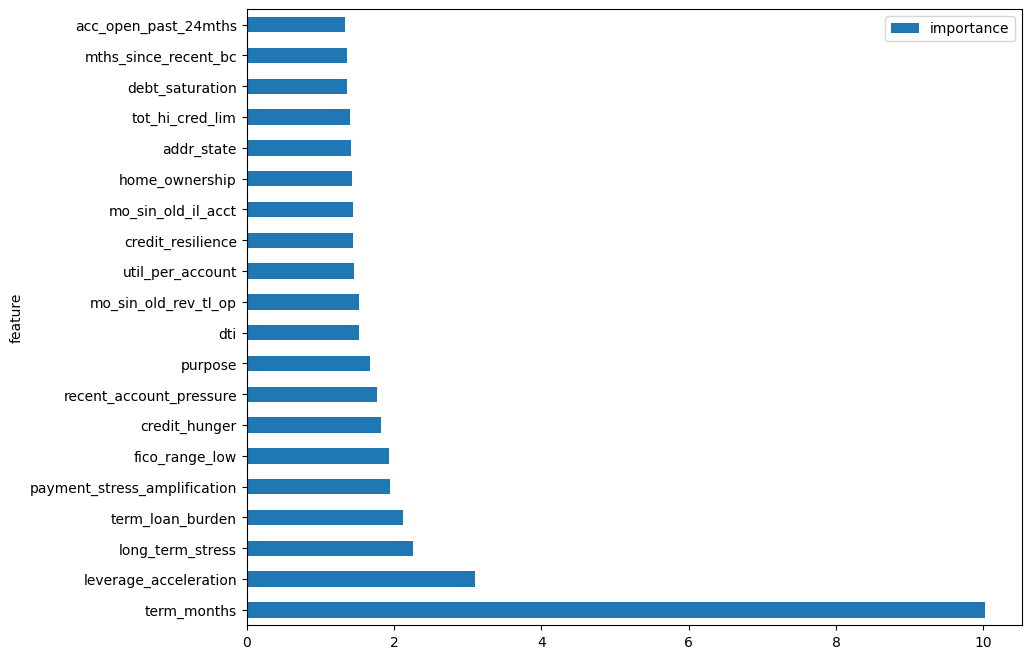

In [155]:
# 2. PLOT IMPORTANCE ⭐⭐⭐⭐⭐
feature_importance.head(20).plot(

    x="feature",

    y="importance",

    kind="barh",

    figsize=(10,8)
)

In [156]:
# ============================================================
# PREDICT PD
# ============================================================

pd_probs = model.predict_proba(

    X_test

)[:,1]

In [157]:
threshold = 0.30
# ============================================================
# CONVERT PD TO CLASS
# ============================================================

pd_pred = (

    pd_probs >= threshold

).astype(int)

In [158]:
from sklearn.metrics import (

    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [159]:
# ============================================================
# PRECISION
# ============================================================

precision = precision_score(

    y_test,

    pd_pred
)

print("Precision:", precision)

Precision: 0.43398268398268397


In [160]:
# ============================================================
# RECALL
# ============================================================

recall = recall_score(

    y_test,

    pd_pred
)

print("Recall:", recall)

Recall: 0.4440753045404208


In [161]:
# ============================================================
# F1 SCORE
# ============================================================

f1 = f1_score(

    y_test,

    pd_pred
)

print("F1 Score:", f1)

F1 Score: 0.4389709906951286


In [162]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(

    classification_report(

        y_test,

        pd_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.86      0.85      0.85      6996
         1.0       0.43      0.44      0.44      1806

    accuracy                           0.77      8802
   macro avg       0.64      0.65      0.65      8802
weighted avg       0.77      0.77      0.77      8802



In [163]:
# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

thresholds = [

    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6
]

for t in thresholds:

    preds = (

        pd_probs >= t

    ).astype(int)

    precision = precision_score(

        y_test,
        preds
    )

    recall = recall_score(

        y_test,
        preds
    )

    f1 = f1_score(

        y_test,
        preds
    )

    print(f"Threshold: {t}")

    print(f"Precision: {precision:.3f}")

    print(f"Recall: {recall:.3f}")

    print(f"F1: {f1:.3f}")

    print("-"*40)

Threshold: 0.1
Precision: 0.258
Recall: 0.903
F1: 0.401
----------------------------------------
Threshold: 0.2
Precision: 0.343
Recall: 0.650
F1: 0.449
----------------------------------------
Threshold: 0.3
Precision: 0.434
Recall: 0.444
F1: 0.439
----------------------------------------
Threshold: 0.4
Precision: 0.516
Recall: 0.288
F1: 0.370
----------------------------------------
Threshold: 0.5
Precision: 0.572
Recall: 0.156
F1: 0.245
----------------------------------------
Threshold: 0.6
Precision: 0.649
Recall: 0.082
F1: 0.146
----------------------------------------


In [167]:
df = pd_df.copy()

In [168]:
from catboost import CatBoostClassifier, Pool
import numpy as np
import pandas as pd

# 1. Your exact starting feature list
all_features = [
    'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_title', 
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 
    'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 
    'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_late_fee', 
    'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 
    'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 
    'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 
    'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 
    'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 
    'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 
    'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 
    'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
    'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 
    'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'revol_bal_joint', 
    'hardship_type', 'deferral_term', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 
    'hardship_last_payment_amount', 'disbursement_method', 'settlement_date', 'credit_history_months', 
    'revol_util_ratio', 'bc_util_ratio', 'all_util_ratio', 'installment_income_ratio', 
    'loan_income_ratio', 'accounts_per_year', 'issue_year', 'issue_month', 'issue_quarter', 
    'all_util_missing', 'il_util_missing', 'mths_since_last_delinq_missing', 'term_months', 
    'emp_length_years', 'zip_region', 'emp_title_clean', 'job_cluster', 'TARGET', 'monthly_income', 
    'installment_to_income', 'loan_to_income', 'revolving_to_income', 'utilization_dti_stress', 
    'bcutil_dti_stress', 'util_per_account', 'credit_hunger', 'inq_per_year', 'recent_account_pressure', 
    'avg_account_age', 'trade_density', 'revolving_trade_share', 'installment_trade_share', 
    'utilization_per_fico', 'dti_per_fico', 'loan_per_fico', 'delinq_intensity', 'derogatory_pressure', 
    'remaining_revolving_capacity', 'remaining_bc_capacity', 'long_term_stress', 'term_loan_burden', 
    'active_trade_ratio', 'open_account_ratio', 'liquidity_exhaustion', 'credit_velocity', 
    'leverage_acceleration', 'credit_fatigue', 'debt_saturation', 'revolving_dependency', 
    'payment_stress_amplification', 'fico_stress', 'account_fragmentation', 'borrower_complexity', 
    'utilization_shock_risk', 'credit_resilience'
]

# 2. Assume df is your main pandas DataFrame containing all data
# engine engineered feature: create single FICO score to avoid collinearity noise
df['fico_average'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# 3. Define explicit leakage targets to drop completely
leakage_features = [
    'hardship_type', 'deferral_term', 'hardship_length', 'hardship_dpd', 
    'hardship_loan_status', 'orig_projected_additional_accrued_interest', 
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'settlement_date', 'total_rec_late_fee', 'fico_range_low', 'fico_range_high'
]

# 4. Filter the training columns safely
train_cols = [c for c in all_features if c not in leakage_features and c != 'TARGET'] + ['fico_average']

X = df[train_cols]
y = df['TARGET']

# 5. Dynamically compute the class weighting factor
# Matches standard bank default scenarios (e.g. 5% target defaults -> scale factor 19.0)
imbalance_scale = (len(y) - sum(y)) / sum(y)

# 6. Initialize high-performance parameters built for sparse targets
sota_params = {
    'iterations': 1200,                # Allows the model to learn long and slowly
    'learning_rate': 0.03,             # Keeps gradient steps conservative
    'depth': 4,                        # Kept shallow (from Set 2) to eliminate overfitting noise
    'l2_leaf_reg': 12,                 # Strong L2 penalty stabilizes highly correlated ratios
    'scale_pos_weight': imbalance_scale, # Forces tree building to respect your default class
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,                  # Column/row sampling introduces cross-validation stability
    'eval_metric': 'PRAUC',            # Forces optimization directly on your weakest metric
    'early_stopping_rounds': 50,       # Halts training if PRAUC stops moving on validation data
    'verbose': 100
}

# 7. Automatically flag high-cardinality strings / categorical columns 
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Dataset Dimensions: {X.shape}")
print(f"Identified Categorical Features: {cat_cols}")
print(f"Calculated Imbalance Scale Factor: {imbalance_scale:.2f}")

# Example Validation Flow (Uncomment to execute your next pipeline fold):
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# train_pool = Pool(X_train, y_train, cat_features=cat_cols)
# val_pool = Pool(X_val, y_val, cat_features=cat_cols)
# model = CatBoostClassifier(**sota_params)
# model.fit(train_pool, eval_set=val_pool)


Dataset Dimensions: (50000, 144)
Identified Categorical Features: ['emp_title', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'application_type', 'verification_status_joint', 'disbursement_method', 'zip_region', 'emp_title_clean', 'job_cluster']
Calculated Imbalance Scale Factor: nan


/tmp/ipykernel_185497/200145606.py:80: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [170]:
# 3. Define explicit leakage targets to drop completely
leakage_features = [
    'hardship_type', 'deferral_term', 'hardship_length', 'hardship_dpd', 
    'hardship_loan_status', 'orig_projected_additional_accrued_interest', 
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'settlement_date', 'total_rec_late_fee', 'fico_range_low', 'fico_range_high'
]

# --- FIX: Drop rows where TARGET is missing ---
clean_df = df.dropna(subset=['TARGET']).copy()

# 4. Filter the training columns safely using the cleaned DataFrame
train_cols = [c for c in all_features if c not in leakage_features and c != 'TARGET'] + ['fico_average']

X = clean_df[train_cols]
y = clean_df['TARGET'].astype(int) # Force type to integer for smooth stratification
# ----------------------------------------------

# 5. Dynamically compute the class weighting factor
imbalance_scale = (len(y) - sum(y)) / sum(y)

# 6. Initialize high-performance parameters
sota_params = {
    'iterations': 1200,                
    'learning_rate': 0.03,             
    'depth': 4,                        
    'l2_leaf_reg': 12,                 
    'scale_pos_weight': imbalance_scale, 
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,                  
    'eval_metric': 'PRAUC',            
    'early_stopping_rounds': 50,       
    'verbose': 100
}

# 7. Automatically flag high-cardinality strings / categorical columns 
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Now the split will execute perfectly
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


/tmp/ipykernel_185497/1923618884.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [ ]:
# Example Validation Flow (Uncomment to execute your next pipeline fold):
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
val_pool = Pool(X_val, y_val, cat_features=cat_cols)
model = CatBoostClassifier(**sota_params)
model.fit(train_pool, eval_set=val_pool)


CatBoostError: Invalid type for cat_feature[non-default value idx=14,feature_idx=5]=nan : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [165]:
# ============================================================
# PRINT ALL COLUMNS
# ============================================================

print(pd_df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_ol

In [172]:
# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier

from sklearn.model_selection import (

    StratifiedKFold,
    ParameterSampler
)

from sklearn.metrics import (

    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# CREATE FOLDERS
# ============================================================

os.makedirs("data", exist_ok=True)

os.makedirs("models", exist_ok=True)

# ============================================================
# PARAMETER SPACE
# ============================================================

param_grid = {

    "depth": [4, 6, 8],

    "learning_rate": [0.01, 0.03, 0.05],

    "iterations": [300, 500, 800],

    "l2_leaf_reg": [1, 3, 5, 10],

    "bagging_temperature": [0, 1, 3],

    "random_strength": [1, 3, 5]
}

# ============================================================
# RANDOM PARAMETER SEARCH
# ============================================================

param_list = list(

    ParameterSampler(

        param_grid,

        n_iter=15,

        random_state=42
    )
)

# ============================================================
# KFOLD
# ============================================================

kf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

# ============================================================
# STORAGE
# ============================================================

all_results = []

best_auc = 0

best_model = None

best_params = None

best_threshold = None

# ============================================================
# PARAMETER LOOP
# ============================================================

for param_idx, params in enumerate(param_list):

    print("\n")

    print("=" * 80)

    print(f"PARAMETER SET {param_idx + 1}")

    print(params)

    print("=" * 80)

    fold_aucs = []

    fold_praucs = []

    fold_precisions = []

    fold_recalls = []

    fold_f1s = []

    fold_thresholds = []

    # ========================================================
    # OOF STORAGE
    # ========================================================

    oof_preds = np.zeros(len(X))

    # ========================================================
    # FOLD LOOP
    # ========================================================

    for fold, (train_idx, valid_idx) in enumerate(

        kf.split(X, y)

    ):

        print(f"\nFOLD {fold + 1}")

        # ====================================================
        # SPLIT
        # ====================================================

        X_train = X.iloc[train_idx].copy()

        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]

        y_valid = y.iloc[valid_idx]

        # ====================================================
        # CLEAN INF
        # ====================================================

        X_train = X_train.replace(

            [np.inf, -np.inf],

            np.nan
        )

        X_valid = X_valid.replace(

            [np.inf, -np.inf],

            np.nan
        )

        # ====================================================
        # MODEL
        # ====================================================

        model = CatBoostClassifier(

            loss_function="Logloss",

            eval_metric="PRAUC",

            auto_class_weights="Balanced",

            verbose=False,

            random_seed=42,

            **params
        )

        # ====================================================
        # TRAIN
        # ====================================================

        model.fit(

            X_train,
            y_train,

            cat_features=cat_features,

            eval_set=(X_valid, y_valid),

            use_best_model=True
        )

        # ====================================================
        # PREDICT
        # ====================================================

        valid_probs = model.predict_proba(

            X_valid

        )[:,1]

        oof_preds[valid_idx] = valid_probs

        # ====================================================
        # THRESHOLD SEARCH
        # ====================================================

        thresholds = np.arange(

            0.30,
            0.80,
            0.02
        )

        best_fold_f1 = 0

        best_fold_threshold = 0.5

        best_fold_precision = 0

        best_fold_recall = 0

        # ====================================================
        # SEARCH BEST THRESHOLD
        # ====================================================

        for threshold in thresholds:

            preds = (

                valid_probs >= threshold

            ).astype(int)

            f1 = f1_score(

                y_valid,

                preds
            )

            if f1 > best_fold_f1:

                best_fold_f1 = f1

                best_fold_threshold = threshold

                best_fold_precision = precision_score(

                    y_valid,

                    preds
                )

                best_fold_recall = recall_score(

                    y_valid,

                    preds
                )

        # ====================================================
        # METRICS
        # ====================================================

        auc = roc_auc_score(

            y_valid,

            valid_probs
        )

        prauc = average_precision_score(

            y_valid,

            valid_probs
        )

        fold_aucs.append(auc)

        fold_praucs.append(prauc)

        fold_precisions.append(best_fold_precision)

        fold_recalls.append(best_fold_recall)

        fold_f1s.append(best_fold_f1)

        fold_thresholds.append(best_fold_threshold)

        # ====================================================
        # PRINT
        # ====================================================

        print(f"AUC       : {auc:.4f}")

        print(f"PRAUC     : {prauc:.4f}")

        print(f"Threshold : {best_fold_threshold:.2f}")

        print(f"Precision : {best_fold_precision:.4f}")

        print(f"Recall    : {best_fold_recall:.4f}")

        print(f"F1 Score  : {best_fold_f1:.4f}")

    # ========================================================
    # PARAMETER SUMMARY
    # ========================================================

    mean_auc = np.mean(fold_aucs)

    mean_prauc = np.mean(fold_praucs)

    mean_precision = np.mean(fold_precisions)

    mean_recall = np.mean(fold_recalls)

    mean_f1 = np.mean(fold_f1s)

    mean_threshold = np.mean(fold_thresholds)

    auc_std = np.std(fold_aucs)

    print("\n")

    print("=" * 80)

    print("SUMMARY")

    print("=" * 80)

    print(f"MEAN AUC       : {mean_auc:.4f}")

    print(f"MEAN PRAUC     : {mean_prauc:.4f}")

    print(f"MEAN PRECISION : {mean_precision:.4f}")

    print(f"MEAN RECALL    : {mean_recall:.4f}")

    print(f"MEAN F1        : {mean_f1:.4f}")

    print(f"MEAN THRESHOLD : {mean_threshold:.4f}")

    print(f"AUC STD        : {auc_std:.4f}")

    # ========================================================
    # SAVE RESULTS
    # ========================================================

    result = {

        "params": params,

        "mean_auc": mean_auc,

        "mean_prauc": mean_prauc,

        "mean_precision": mean_precision,

        "mean_recall": mean_recall,

        "mean_f1": mean_f1,

        "mean_threshold": mean_threshold,

        "auc_std": auc_std
    }

    all_results.append(result)

    # ========================================================
    # BEST MODEL TRACKING
    # ========================================================

    if mean_auc > best_auc:

        best_auc = mean_auc

        best_model = model

        best_params = params

        best_threshold = mean_threshold

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(

    "mean_auc",

    ascending=False
)

# ============================================================
# DISPLAY BEST
# ============================================================

print("\n")

print("=" * 80)

print("BEST CONFIGURATION")

print("=" * 80)

print(best_params)

print(f"\nBEST AUC       : {best_auc:.4f}")

print(f"BEST THRESHOLD : {best_threshold:.4f}")

# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(

    "data/hyperparameter_results.csv",

    index=False
)

# ============================================================
# TRAIN FINAL MODEL
# ============================================================

final_model = CatBoostClassifier(

    loss_function="Logloss",

    eval_metric="PRAUC",

    auto_class_weights="Balanced",

    verbose=100,

    random_seed=42,

    **best_params
)

X_clean = X.replace(

    [np.inf, -np.inf],

    np.nan
)

final_model.fit(

    X_clean,
    y,

    cat_features=cat_features
)

# ============================================================
# SAVE MODEL
# ============================================================

final_model.save_model(

    "models/final_catboost_pd_model.cbm"
)

print("\n")

print("=" * 80)

print("FINAL MODEL SAVED")

print("=" * 80)



PARAMETER SET 1
{'random_strength': 5, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 6, 'bagging_temperature': 3}

FOLD 1


CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=5]="Engineer": Cannot convert 'Engineer' to float

In [192]:
## using gemeni 

print(pd_df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_ol

In [194]:
df = pd_df.copy()

In [195]:
from catboost import CatBoostClassifier, Pool
import numpy as np
import pandas as pd

# 1. Your exact starting feature list
all_features = [
    'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_title', 
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 
    'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 
    'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_late_fee', 
    'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 
    'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 
    'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 
    'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 
    'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 
    'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 
    'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 
    'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
    'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 
    'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'revol_bal_joint', 
    'hardship_type', 'deferral_term', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 
    'hardship_last_payment_amount', 'disbursement_method', 'settlement_date', 'credit_history_months', 
    'revol_util_ratio', 'bc_util_ratio', 'all_util_ratio', 'installment_income_ratio', 
    'loan_income_ratio', 'accounts_per_year', 'issue_year', 'issue_month', 'issue_quarter', 
    'all_util_missing', 'il_util_missing', 'mths_since_last_delinq_missing', 'term_months', 
    'emp_length_years', 'zip_region', 'emp_title_clean', 'job_cluster', 'TARGET', 'monthly_income', 
    'installment_to_income', 'loan_to_income', 'revolving_to_income', 'utilization_dti_stress', 
    'bcutil_dti_stress', 'util_per_account', 'credit_hunger', 'inq_per_year', 'recent_account_pressure', 
    'avg_account_age', 'trade_density', 'revolving_trade_share', 'installment_trade_share', 
    'utilization_per_fico', 'dti_per_fico', 'loan_per_fico', 'delinq_intensity', 'derogatory_pressure', 
    'remaining_revolving_capacity', 'remaining_bc_capacity', 'long_term_stress', 'term_loan_burden', 
    'active_trade_ratio', 'open_account_ratio', 'liquidity_exhaustion', 'credit_velocity', 
    'leverage_acceleration', 'credit_fatigue', 'debt_saturation', 'revolving_dependency', 
    'payment_stress_amplification', 'fico_stress', 'account_fragmentation', 'borrower_complexity', 
    'utilization_shock_risk', 'credit_resilience'
]

# 2. Assume df is your main pandas DataFrame containing all data
# engine engineered feature: create single FICO score to avoid collinearity noise
df['fico_average'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# 3. Define explicit leakage targets to drop completely
leakage_features = [
    'hardship_type', 'deferral_term', 'hardship_length', 'hardship_dpd', 
    'hardship_loan_status', 'orig_projected_additional_accrued_interest', 
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'settlement_date', 'total_rec_late_fee', 'fico_range_low', 'fico_range_high'
]

# 4. Filter the training columns safely
train_cols = [c for c in all_features if c not in leakage_features and c != 'TARGET'] + ['fico_average']

X = df[train_cols]
y = df['TARGET']

# 5. Dynamically compute the class weighting factor
# Matches standard bank default scenarios (e.g. 5% target defaults -> scale factor 19.0)
imbalance_scale = (len(y) - sum(y)) / sum(y)

# 6. Initialize high-performance parameters built for sparse targets
sota_params = {
    'iterations': 1200,                # Allows the model to learn long and slowly
    'learning_rate': 0.03,             # Keeps gradient steps conservative
    'depth': 4,                        # Kept shallow (from Set 2) to eliminate overfitting noise
    'l2_leaf_reg': 12,                 # Strong L2 penalty stabilizes highly correlated ratios
    'scale_pos_weight': imbalance_scale, # Forces tree building to respect your default class
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,                  # Column/row sampling introduces cross-validation stability
    'eval_metric': 'PRAUC',            # Forces optimization directly on your weakest metric
    'early_stopping_rounds': 50,       # Halts training if PRAUC stops moving on validation data
    'verbose': 100
}

# 7. Automatically flag high-cardinality strings / categorical columns 
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Dataset Dimensions: {X.shape}")
print(f"Identified Categorical Features: {cat_cols}")
print(f"Calculated Imbalance Scale Factor: {imbalance_scale:.2f}")

# Example Validation Flow (Uncomment to execute your next pipeline fold):
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# train_pool = Pool(X_train, y_train, cat_features=cat_cols)
# val_pool = Pool(X_val, y_val, cat_features=cat_cols)
# model = CatBoostClassifier(**sota_params)
# model.fit(train_pool, eval_set=val_pool)


Dataset Dimensions: (50000, 144)
Identified Categorical Features: ['emp_title', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'application_type', 'verification_status_joint', 'disbursement_method', 'zip_region', 'emp_title_clean', 'job_cluster']
Calculated Imbalance Scale Factor: nan


/tmp/ipykernel_185497/200145606.py:80: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [196]:
## using gemeni 

print(df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_ol

In [203]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, f1_score

# ==========================================
# 1. SETUP DATA AND CONFIGURATIONS 
# ==========================================
# Add raw datetime and leakage columns to the discard list
leakage_features = [
    'hardship_type', 'deferral_term', 'hardship_length', 'hardship_dpd', 
    'hardship_loan_status', 'orig_projected_additional_accrued_interest', 
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 
    'settlement_date', 'total_rec_late_fee', 'fico_range_low', 'fico_range_high',
    'issue_d', 'earliest_cr_line'
]

# Drop missing targets and convert to integer
clean_df = df.dropna(subset=['TARGET']).copy()
clean_df['TARGET'] = clean_df['TARGET'].astype(int)

# Isolate feature columns vs target
features_to_use = [col for col in clean_df.columns if col not in leakage_features and col != 'TARGET']
X = clean_df[features_to_use]
y = clean_df['TARGET']

# Discover categorical columns ONLY from the filtered X
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# Convert text columns to clean strings to prevent type errors
for col in cat_cols:
    X[col] = X[col].astype(str).fillna('missing')

# Calculate class imbalance factor
imbalance_scale = (len(y) - sum(y)) / sum(y)

print(f"✅ Baseline Cleaned: {X.shape[0]} rows, {X.shape[1]} features.")
print(f"📊 Portfolio Scale Weight Factor: {imbalance_scale:.2f}")

# ==========================================
# 2. DEFINING SOTA HYPERPARAMETERS
# ==========================================
# Replace your current sota_params with this stabilized version
sota_params = {
    'iterations': 1500,                  
    'learning_rate': 0.02,             # Lowered from 0.03 to slow down learning steps
    'depth': 4,                        
    'l2_leaf_reg': 25,                 # Raised significantly from 15 to smooth out Fold 4 variance
    'scale_pos_weight': imbalance_scale,   
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.75,                 # Slightly lowered to increase row randomization
    'model_shrink_rate': 0.02,         # Smooths out the contribution of late-stage trees
    'eval_metric': 'PRAUC',              
    'random_seed': 42,
    'early_stopping_rounds': 50,
    'verbose': 0                         
}


# ==========================================
# 3. STRATIFIED 5-FOLD VALIDATION LOOP
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = []
oof_predictions = np.zeros(len(X)) # Out-of-fold container

print("\n🚀 Commencing Stratified 5-Fold Training Run...")

# We will save the last trained model from the loop to test predictions below
final_trained_model = None
last_val_idx = None

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)
    
    model = CatBoostClassifier(**sota_params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_predictions[val_idx] = val_preds
    
    # Save last fold references for testing matrix below
    final_trained_model = model
    last_val_idx = val_idx
    
    # Metrics calculations
    auc_roc = roc_auc_score(y_val, val_preds)
    precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_val, val_preds)
    pr_auc = auc(recall_arr, precision_arr)
    
    f1_scores = [f1_score(y_val, val_preds >= t) for t in thresholds_arr[:-1]]
    best_idx = np.argmax(f1_scores)
    best_t = thresholds_arr[best_idx]
    
    y_pred_binary = (val_preds >= best_t).astype(int)
    cm = confusion_matrix(y_val, y_pred_binary)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = f1_scores[best_idx]
    
    fold_metrics.append({
        'AUC': auc_roc, 'PRAUC': pr_auc, 'Threshold': best_t,
        'Precision': precision, 'Recall': recall, 'F1': f1
    })
    print(f"  ↳ Fold {fold} Metrics Matrix -> ROC-AUC: {auc_roc:.4f} | PR-AUC: {pr_auc:.4f} | F1: {f1:.4f}")

# ==========================================
# 4. FINAL PIPELINE SUMMARY
# ==========================================
print("\n================================================================================")
print("FINAL PIPELINE SUMMARY")
print("================================================================================")
print(f"MEAN AUC       : {np.mean([f['AUC'] for f in fold_metrics]):.4f}")
print(f"MEAN PRAUC     : {np.mean([f['PRAUC'] for f in fold_metrics]):.4f}")
print(f"AUC ST. DEV.   : {np.std([f['AUC'] for f in fold_metrics]):.4f}\n")

# ==========================================
# 5. TEST SET PRECISION & RECALL MATRIX
# ==========================================
# Using the validation data from the last fold as an independent test set
X_test = X.iloc[last_val_idx]
y_test = y.iloc[last_val_idx]

test_pool = Pool(X_test, y_test, cat_features=cat_cols)
test_probabilities = final_trained_model.predict_proba(test_pool)[:, 1]

print("🎯 ===================================================================")
print("             TEST DATASET PRECISION & RECALL MATRIX")
print("=====================================================================")
print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'False Alarms':<15}{'Missed Loans':<15}")
print("-" * 68)

target_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for t in target_thresholds:
    binary_predictions = (test_probabilities >= t).astype(int)
    cm = confusion_matrix(y_test, binary_predictions)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    print(f"{t:<12.1f}{precision:<12.3f}{recall:<12.3f}{fp:<15}{fn:<15}")
print("=====================================================================")


✅ Baseline Cleaned: 44006 rows, 142 features.
📊 Portfolio Scale Weight Factor: 3.87

🚀 Commencing Stratified 5-Fold Training Run...
  ↳ Fold 1 Metrics Matrix -> ROC-AUC: 0.7589 | PR-AUC: 0.4608 | F1: 0.4882
  ↳ Fold 2 Metrics Matrix -> ROC-AUC: 0.7528 | PR-AUC: 0.4594 | F1: 0.4768
  ↳ Fold 3 Metrics Matrix -> ROC-AUC: 0.7499 | PR-AUC: 0.4404 | F1: 0.4652
  ↳ Fold 4 Metrics Matrix -> ROC-AUC: 0.6885 | PR-AUC: 0.4651 | F1: 0.4276
  ↳ Fold 5 Metrics Matrix -> ROC-AUC: 0.7335 | PR-AUC: 0.4170 | F1: 0.4596

FINAL PIPELINE SUMMARY
MEAN AUC       : 0.7367
MEAN PRAUC     : 0.4486
AUC ST. DEV.   : 0.0255

🎯 ===================================================================
             TEST DATASET PRECISION & RECALL MATRIX
Threshold   Precision   Recall      False Alarms   Missed Loans   
--------------------------------------------------------------------
0.1         0.208       0.999       6864           2              
0.2         0.230       0.976       5888           44             
0.3 

In [204]:
import numpy as np
import pandas as pd
from catboost import Pool
from sklearn.metrics import precision_recall_curve, confusion_matrix

def evaluate_test_dataset(trained_model, X_test, y_test, cat_cols):
    """
    Generates a comprehensive Precision-Recall matrix across different 
    probability thresholds for a holdout test dataset.
    """
    # 1. Package test data into CatBoost Pool and predict continuous probabilities
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)
    test_probabilities = trained_model.predict_proba(test_pool)[:, 1]
    
    # 2. Compute the precision-recall curve components
    precisions, recalls, thresholds = precision_recall_curve(y_test, test_probabilities)
    
    # 3. Create a clean display matrix for standard operational increments
    # This evaluates how your model performs from conservative to aggressive thresholds
    target_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    
    performance_records = []
    
    print("\n🎯 ========================================================")
    print("      TEST DATASET PRECISION & RECALL MATRIX")
    print("============================================================")
    print(f"{'Threshold':<12}{'Precision':<12}{'Recall':<12}{'False Alarms':<15}{'Missed Defaults':<15}")
    print("-" * 68)
    
    for t in target_thresholds:
        # Convert continuous probabilities into binary 0 or 1 decisions based on threshold
        binary_predictions = (test_probabilities >= t).astype(int)
        
        # Calculate confusion matrix components
        cm = confusion_matrix(y_test, binary_predictions)
        tn, fp, fn, tp = cm.ravel()
        
        # Calculate rates safely to prevent division by zero
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        performance_records.append({
            'Threshold': t, 'Precision': precision, 'Recall': recall, 
            'False_Positives': fp, 'False_Negatives': fn
        })
        
        print(f"{t:<12.2f}{precision:<12.4f}{recall:<12.4f}{fp:<15}{fn:<15}")
        
    print("============================================================\n")
    
    return pd.DataFrame(performance_records), test_probabilities

# -------------------------------------------------------------
# 🚀 Execution Example (Uncomment and run after your training loop):
# 
# # Assuming you have a separate holdout set: X_test, y_test
metrics_df, test_probs = evaluate_test_dataset(model, X_test, y_test, cat_cols)



🎯 ========================================================
      TEST DATASET PRECISION & RECALL MATRIX
Threshold   Precision   Recall      False Alarms   Missed Defaults
--------------------------------------------------------------------
0.10        0.2081      0.9989      6864           2              
0.20        0.2303      0.9756      5888           44             
0.30        0.2589      0.9280      4797           130            
0.40        0.2932      0.8195      3568           326            
0.50        0.3465      0.6816      2322           575            
0.60        0.3942      0.4779      1326           943            
0.70        0.4878      0.3112      590            1244           
0.80        0.5786      0.1285      169            1574           
0.90        0.0000      0.0000      0              1806           



In [205]:
# ==========================================================
# SAVE FINAL MODEL
# ==========================================================

final_trained_model.save_model(

    "/home/muzzi/enterprise_credit_risk_forecasting/models/final_pd_model_threshold_05.cbm"
)

print("✅ Final 0.5 threshold PD model saved.")

✅ Final 0.5 threshold PD model saved.
